In [5]:
library(JuliaConnectoR)
.ensure_julia_ready()



In [9]:
# Código en R 
j_eval <- function(cmd) {
  .ensure_julia_ready()
  lineas <- strsplit(cmd, "\n")[[1]]
  buffer_bloque <- ""; en_bloque <- 0; resultado_final <- NULL

  for (l in lineas) {
    if (trimws(l) == "") next
    buffer_bloque <- paste0(buffer_bloque, l, "\n")
    abrir <- grepl("\\b(do|function|for|if|begin|let|while)\\b", l) & !grepl("\\bend\\b", l)
    cerrar <- grepl("\\bend\\b", l)
    en_bloque <- en_bloque + abrir - cerrar
    
    if (en_bloque <= 0) {
      res_raw <- JuliaConnectoR::juliaCall("Main._unal_core_executor", buffer_bloque, FALSE, "", 72, 800, 500, 12)
      cat(res_raw)
      lineas_res <- strsplit(res_raw, "\n")[[1]]
      lineas_res <- trimws(lineas_res[lineas_res != ""])
      # Capturamos solo si hay contenido real
      temp_res <- tail(lineas_res[!grepl("^julia>", lineas_res)], 1)
      if (length(temp_res) > 0) resultado_final <- temp_res
      buffer_bloque <- ""; en_bloque <- 0
    }
  }
  if (is.null(resultado_final)) return(NULL) # Evita el error de length zero
  val_limpio <- gsub('"', '', resultado_final)
  num_val <- suppressWarnings(as.numeric(val_limpio))
  return(if (!is.na(num_val)) num_val else val_limpio)
}

j_plot <- function(cmd, n = "tmp_plot.png", dpi = 300, w = 800, h = NULL, ratio = 1.6, fontsize = 12) {
  .ensure_julia_ready()
  if (is.null(h)) h <- round(w / ratio)
  
  lineas <- strsplit(cmd, "\n")[[1]]
  buffer_bloque <- ""; en_bloque <- 0
  
  for (i in 1:length(lineas)) {
    l <- lineas[i]
    if (trimws(l) == "") next
    buffer_bloque <- paste0(buffer_bloque, l, "\n")
    
    # Lógica de detección de bloques (do, function, for, etc.)
    abrir <- grepl("\\b(do|function|for|if|begin|let|while)\\b", l) & !grepl("\\bend\\b", l)
    cerrar <- grepl("\\bend\\b", l)
    en_bloque <- en_bloque + abrir - cerrar
    
    # Solo ejecutamos si el bloque está cerrado
    if (en_bloque <= 0) {
      # ¿Es el último bloque? Si sí, activamos el guardado de imagen (TRUE)
      es_ultimo <- (i == length(lineas))
      
      log_out <- JuliaConnectoR::juliaCall(
        "_unal_core_executor", 
        buffer_bloque, 
        es_ultimo, # Solo la última ejecución guarda el PNG
        n, dpi, as.integer(w), as.integer(h), as.integer(fontsize)
      )
      
      if (nchar(log_out) > 0) cat(log_out)
      buffer_bloque <- ""; en_bloque <- 0
    }
  }
  
  # Renderizado de la imagen en R (solo si se creó el archivo)
  if (file.exists(n)) {
    img <- png::readPNG(n)
    grid::grid.newpage()
    grid::grid.raster(img)
    # Opcional: borrar el temporal después de leerlo para no dejar basura
    # unlink(n) 
  }
}

In [13]:
j_eval("
using Rasters, ArchGDAL, Statistics

Rasters.checkmem!(false)

path = strip(read(\"s2_shared_path.txt\", String))

function process_band_mean(path)
    ArchGDAL.read(path) do ds
        r   = Raster(ds)[Band(1)]
        res = r .* 1.5
        return mean(res)
    end
end

process_band_mean(path)
GC.gc()

t0 = time_ns()
m_julia = process_band_mean(path)
t1 = time_ns()

t_julia = (t1 - t0) / 1e9

println(\"🟣 Julia: \", round(t_julia, digits=3), \" seg | mean = \", round(m_julia, digits=6))

t_julia
")


julia> using Rasters, ArchGDAL, Statistics

julia> Rasters.checkmem!(false)
false

julia> path = strip(read("s2_shared_path.txt", String))
"SENTINEL2_L1C:/vsizip//usr/local/lib/R/site-library/starsdata/sentinel/S2A_MSIL1C_20180220T105051_N0206_R051_T32ULE_20180221T134037.zip/S2A_MSIL1C_20180220T105051_N0206_R051_T32ULE_20180221T134037.SAFE/MTD_MSIL1C.xml:10m:EPSG_32632"

julia> function process_band_mean(path)
    ArchGDAL.read(path) do ds
        r   = Raster(ds)[Band(1)]
        res = r .* 1.5
        return mean(res)
    end
end
process_band_mean (generic function with 1 method)

julia> process_band_mean(path)
3766.6246303263756

julia> GC.gc()

julia> t0 = time_ns()
0x00000d4bfb4e11af

julia> m_julia = process_band_mean(path)
3766.6246303263756

julia> t1 = time_ns()
0x00000d4dc7b8df8f

julia> t_julia = (t1 - t0) / 1e9
7.72451888

julia> println("🟣 Julia: ", round(t_julia, digits=3), " seg | mean = ", round(m_julia, digits=6))
🟣 Julia: 7.725 seg | mean = 3766.62463

julia> t_julia


[1] 7.724519

julia> using Rasters, ArchGDAL, Plots

julia> path = strip(read("s2_shared_path.txt", String))
"SENTINEL2_L1C:/vsizip//usr/local/lib/R/site-library/starsdata/sentinel/S2A_MSIL1C_20180220T105051_N0206_R051_T32ULE_20180221T134037.zip/S2A_MSIL1C_20180220T105051_N0206_R051_T32ULE_20180221T134037.SAFE/MTD_MSIL1C.xml:10m:EPSG_32632"

julia> ArchGDAL.read(path) do ds
    r   = Raster(ds)[Band(1)]
    res = r .* 1.5
    p = plot(res,
             colormap = :terrain,
             title = "Julia: Banda 4 × 1.5")
    savefig(p, "tmp_plot.png")
end
"/home/rstudio/work/PRACTICA_1/tmp_plot.png"



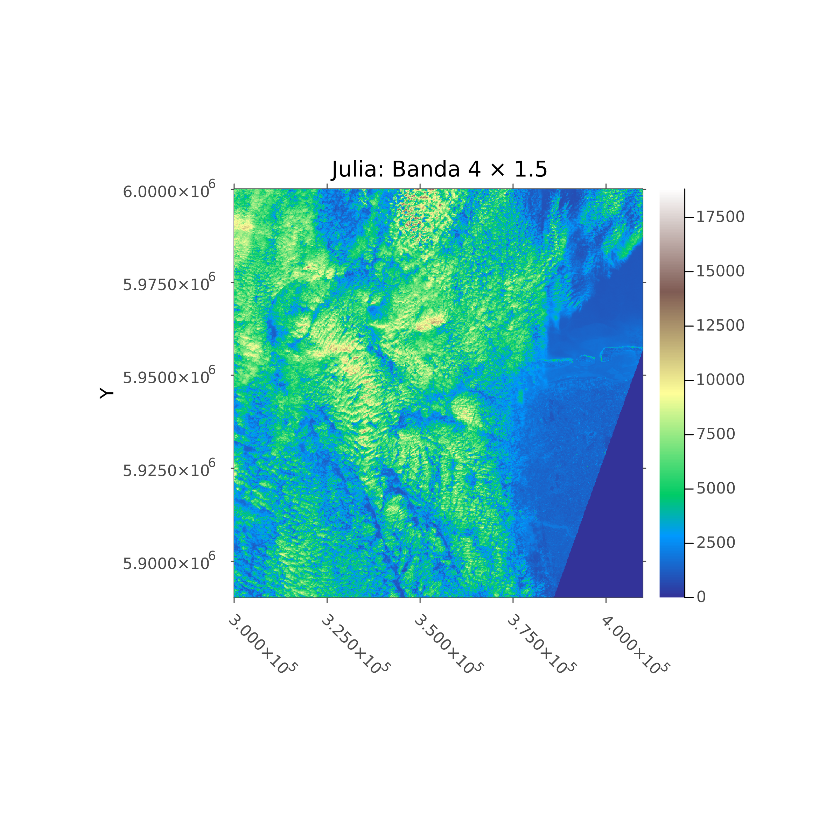

In [15]:
j_plot("
using Rasters, ArchGDAL, Plots

path = strip(read(\"s2_shared_path.txt\", String))

ArchGDAL.read(path) do ds
    r   = Raster(ds)[Band(1)]
    res = r .* 1.5
    p = plot(res,
             colormap = :terrain,
             title = \"Julia: Banda 4 × 1.5\")
    savefig(p, \"tmp_plot.png\")
end
")
